# 02 · EDA — Favorita Grocery Sales

- Wie sieht die Verteilung der Transaktionen aus?
- Welche Saisonalitäten existieren (Wochentag, Monat, Jahr)?
- Gibt es einen Trend?
- Wie stark korrelieren externe Regressoren (Ölpreis, Feiertage)?
- Wie stark ist die Autokorrelation — und welche Lags sind relevant?

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
PROCESSED = Path('..') / '02_data' / 'processed'

In [3]:
tx     = pl.read_parquet(PROCESSED / 'transactions.parquet')
stores = pl.read_parquet(PROCESSED / 'stores.parquet')
oil    = pl.read_parquet(PROCESSED / 'oil.parquet')
hol    = pl.read_parquet(PROCESSED / 'holidays.parquet')

In [4]:
# Arbeits-DataFrame: Transactions + Store-Metadaten + Zeitfeatures
df = (
    tx.join(stores, on='store_nbr', how='left')
    .with_columns([
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.month().alias('month'),
        pl.col('date').dt.year().alias('year'),
    ])
)

print('Shape:', df.shape)
df.head(5)

Shape: (83488, 10)


date,store_nbr,transactions,city,state,type,cluster,weekday,month,year
date,i64,i64,str,str,str,i64,i8,i8,i32
2013-01-01,25,770,"""Salinas""","""Santa Elena""","""D""",1,2,1,2013
2013-01-02,1,2111,"""Quito""","""Pichincha""","""D""",13,3,1,2013
2013-01-02,2,2358,"""Quito""","""Pichincha""","""D""",13,3,1,2013
2013-01-02,3,3487,"""Quito""","""Pichincha""","""D""",8,3,1,2013
2013-01-02,4,1922,"""Quito""","""Pichincha""","""D""",9,3,1,2013


## 1 · Verteilung der Transaktionen

Betrachtung der Transaktionsverteilung über alle Beobachtungen hinweg und den Storetyp. Deutlicher Unterschied für die Storetypen

C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\1629402898.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x='type', y='transactions', order=order,


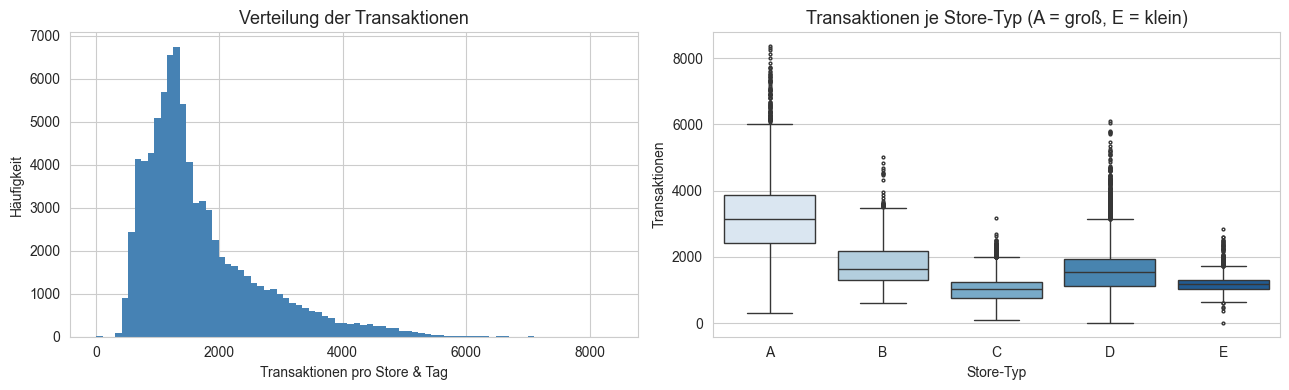

        mean     std  median
type                        
A     3193.1  1038.5  3137.5
B     1756.0   540.4  1645.0
C     1032.1   314.5  1017.0
D     1619.1   705.1  1531.0
E     1188.0   225.2  1164.0


In [5]:
df_pd = df.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_pd['transactions'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Verteilung der Transaktionen', fontsize=13)
axes[0].set_xlabel('Transaktionen pro Store & Tag')
axes[0].set_ylabel('Häufigkeit')

order = ['A', 'B', 'C', 'D', 'E']
sns.boxplot(data=df_pd, x='type', y='transactions', order=order,
            palette='Blues', flierprops={'markersize': 2}, ax=axes[1])
axes[1].set_title('Transaktionen je Store-Typ (A = groß, E = klein)', fontsize=13)
axes[1].set_xlabel('Store-Typ')
axes[1].set_ylabel('Transaktionen')

plt.tight_layout()
plt.show()

print(df_pd.groupby('type')['transactions'].agg(['mean','std','median']).round(1))

## 2 · Trend — Jahresentwicklung

Berechnung der durchschnittlichen Transaktionen im Zeitraum. Man sieht deuutlich die täglichen Peaks und den damit verbundenen Anstieg des Monatsmittels

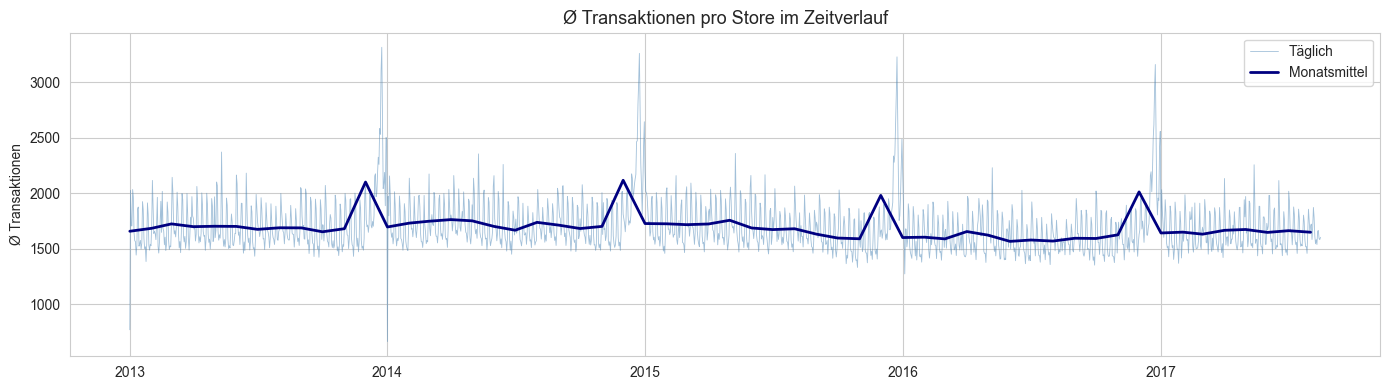

In [6]:
daily_total = (
    df.group_by('date')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('date')
    .to_pandas()
)

monthly_avg = (
    df.with_columns(pl.col('date').dt.truncate('1mo').alias('monat'))
    .group_by('monat')
    .agg(pl.col('transactions').mean().alias('avg_transactions'))
    .sort('monat')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_total['date'], daily_total['avg_transactions'],
        color='steelblue', linewidth=0.6, alpha=0.5, label='Täglich')
ax.plot(monthly_avg['monat'], monthly_avg['avg_transactions'],
        color='navy', linewidth=2, label='Monatsmittel')
ax.set_title('Ø Transaktionen pro Store im Zeitverlauf', fontsize=13)
ax.set_ylabel('Ø Transaktionen')
ax.legend()
plt.tight_layout()
plt.show()



## 3 · Saisonalität — Wochentag & Monat

Die Betrachutng der Monate und Wochentage zeigt deutlich, dass sowohl Ende eines Jahres als auch am Ende einer Woche mehr Transaktionen stattfinden. Das ist insofern logisch, dass am Wochenende mehr verkauft wird und am Jahresende die Umsatzstarken Monate sind.

C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\3930854457.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_avg, x='label', y='avg', palette='Blues', ax=axes[0])
C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\3930854457.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_avg, x='month', y='avg', palette='Blues', ax=axes[1])


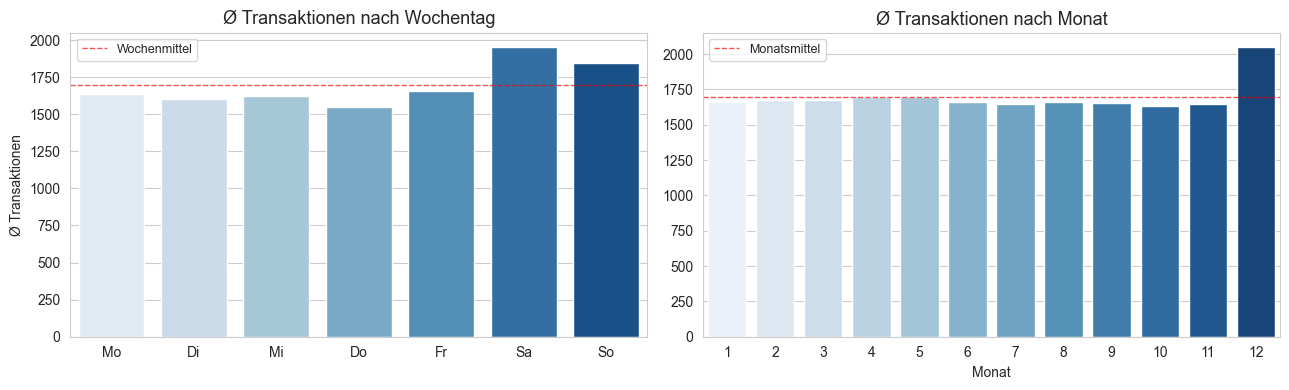

In [7]:
weekday_avg = (
    df.group_by('weekday')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('weekday')
    .to_pandas()
)
weekday_avg['label'] = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

month_avg = (
    df.group_by('month')
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort('month')
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=weekday_avg, x='label', y='avg', palette='Blues', ax=axes[0])
axes[0].set_title('Ø Transaktionen nach Wochentag', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Ø Transaktionen')
axes[0].axhline(weekday_avg['avg'].mean(), color='red', linestyle='--',
                linewidth=1, alpha=0.7, label='Wochenmittel')
axes[0].legend(fontsize=9)

sns.barplot(data=month_avg, x='month', y='avg', palette='Blues', ax=axes[1])
axes[1].set_title('Ø Transaktionen nach Monat', fontsize=13)
axes[1].set_xlabel('Monat')
axes[1].set_ylabel('')
axes[1].axhline(month_avg['avg'].mean(), color='red', linestyle='--',
                linewidth=1, alpha=0.7, label='Monatsmittel')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 4 · Autokorrelation — welche Lags sind relevant?

Basis für das Feature Enginnering und die Patch Lägne. Dies erfolgt beispielhaft für Store1 und über alle Stores hinweg. Die Analyse zeigt dabei sehr gut das sich Lag7 und Lag14 anbieten.


C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\2811071201.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=[f'Lag {l}' for l in key_lags], patch_artist=True)


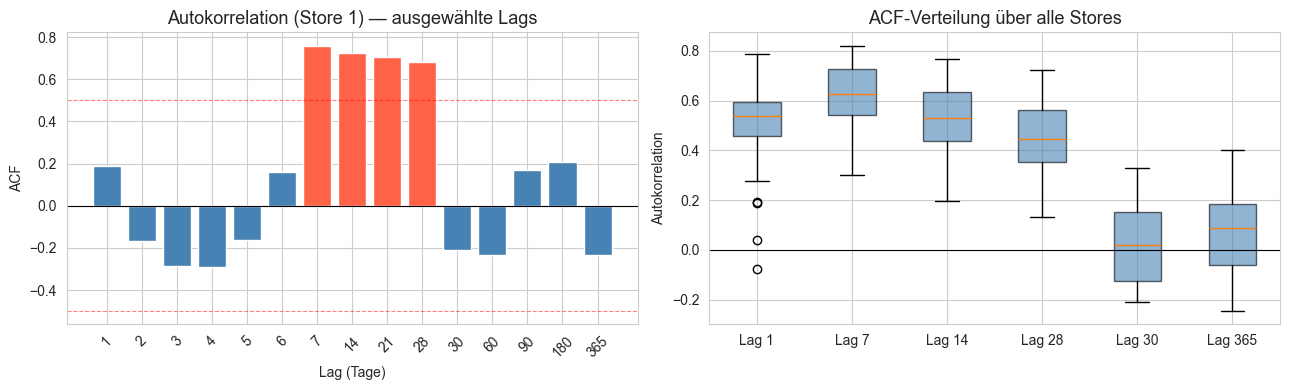

In [8]:
store1 = (
    tx.filter(pl.col('store_nbr') == 1)
    .sort('date')
    .to_pandas()
    .set_index('date')['transactions']
)

lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 30, 60, 90, 180, 365]
acf_vals = [store1.autocorr(lag=l) for l in lags]

key_lags = [1, 7, 14,28, 30, 365]
acf_all = {lag: [] for lag in key_lags}

tx_pd = tx.to_pandas()
for store_id, grp in tx_pd.groupby('store_nbr'):
    s = grp.sort_values('date').set_index('date')['transactions']
    if len(s) < 400:
        continue
    for lag in key_lags:
        if len(s) > lag:
            acf_all[lag].append(s.autocorr(lag=lag))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tomato' if abs(v) > 0.5 else 'steelblue' for v in acf_vals]
axes[0].bar([str(l) for l in lags], acf_vals, color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(-0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('Autokorrelation (Store 1) — ausgewählte Lags', fontsize=13)
axes[0].set_xlabel('Lag (Tage)')
axes[0].set_ylabel('ACF')
axes[0].tick_params(axis='x', rotation=45)

data_box = [acf_all[l] for l in key_lags]
bp = axes[1].boxplot(data_box, labels=[f'Lag {l}' for l in key_lags], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('ACF-Verteilung über alle Stores', fontsize=13)
axes[1].set_ylabel('Autokorrelation')

plt.tight_layout()
plt.show()

## 5 · Externe Regressoren

### 5a · Ölpreis

Kein  Zusammenhang zwischen dem Ölpreis und den Transaktionen

In [9]:
daily_avg = (
    tx.group_by('date')
    .agg(pl.col('transactions').mean().alias('avg_tx'))
    .sort('date')
    .to_pandas()
)

oil_pd = oil.to_pandas().dropna()
merged_oil = daily_avg.merge(oil_pd, on='date', how='inner')
merged_oil

,date,avg_tx,dcoilwtico
0,2013-01-02,2026.413043,93.14
1,2013-01-03,1706.608696,92.97
2,2013-01-04,1706.391304,93.12
3,2013-01-07,1643.413043,93.20
4,2013-01-08,1572.282609,93.21
...,...,...,...
1158,2017-08-09,1582.444444,49.59
1159,2017-08-10,1538.222222,48.54
1160,2017-08-11,1658.351852,48.81
1161,2017-08-14,1582.370370,47.59


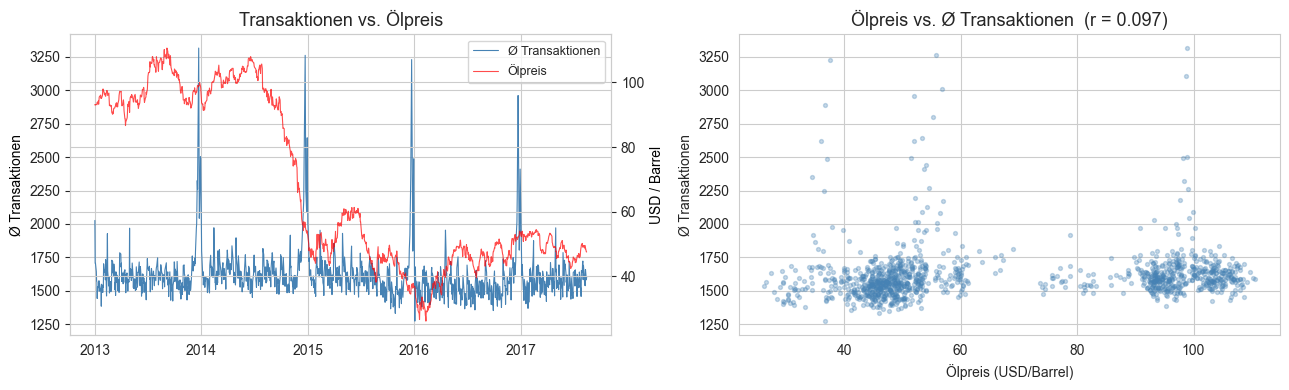

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(merged_oil['date'], merged_oil['avg_tx'],
         color='steelblue', linewidth=0.8, label='Ø Transaktionen')
ax2.plot(merged_oil['date'], merged_oil['dcoilwtico'],
         color='red', linewidth=0.8, alpha=0.7, label='Ölpreis')
ax1.set_title('Transaktionen vs. Ölpreis', fontsize=13)
ax1.set_ylabel('Ø Transaktionen', color='black')
ax2.set_ylabel('USD / Barrel', color='black')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

axes[1].scatter(merged_oil['dcoilwtico'], merged_oil['avg_tx'],
                alpha=0.3, s=8, color='steelblue')
corr = merged_oil[['dcoilwtico', 'avg_tx']].corr().iloc[0, 1]
axes[1].set_title(f'Ölpreis vs. Ø Transaktionen  (r = {corr:.3f})', fontsize=13)
axes[1].set_xlabel('Ölpreis (USD/Barrel)')
axes[1].set_ylabel('Ø Transaktionen')

plt.tight_layout()
plt.show()

### 5b · Feiertage

Bei den Feiertagen werden für einen bessern Vergleich nur die Nationalen Feiertage betrachtet. Die Regionalen werden ignoriert

In [12]:
hol_national = (
    hol.filter(pl.col('locale') == 'National')
    .select(['date', 'type'])
    .rename({'type': 'hol_type'})
).to_pandas()


df_hol = daily_avg.merge(hol_national, on='date', how='left')
df_hol["hol_type"] = df_hol["hol_type"].fillna("Normal", inplace = True)

df_hol

C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\1675174459.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_hol["hol_type"] = df_hol["hol_type"].fillna("Normal", inplace = True)


,date,avg_tx,hol_type
0,2013-01-01,770.000000,Holiday
1,2013-01-02,2026.413043,Normal
2,2013-01-03,1706.608696,Normal
3,2013-01-04,1706.391304,Normal
4,2013-01-05,2034.195652,Work Day
...,...,...,...
1681,2017-08-11,1658.351852,Transfer
1682,2017-08-12,1665.314815,Normal
1683,2017-08-13,1592.462963,Normal
1684,2017-08-14,1582.370370,Normal


## Analyse der Feiertage und Verteilung

## 

C:\Users\maxkr\AppData\Local\Temp\ipykernel_10556\3091989869.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hol, x='hol_type', y='avg_tx', order=order,


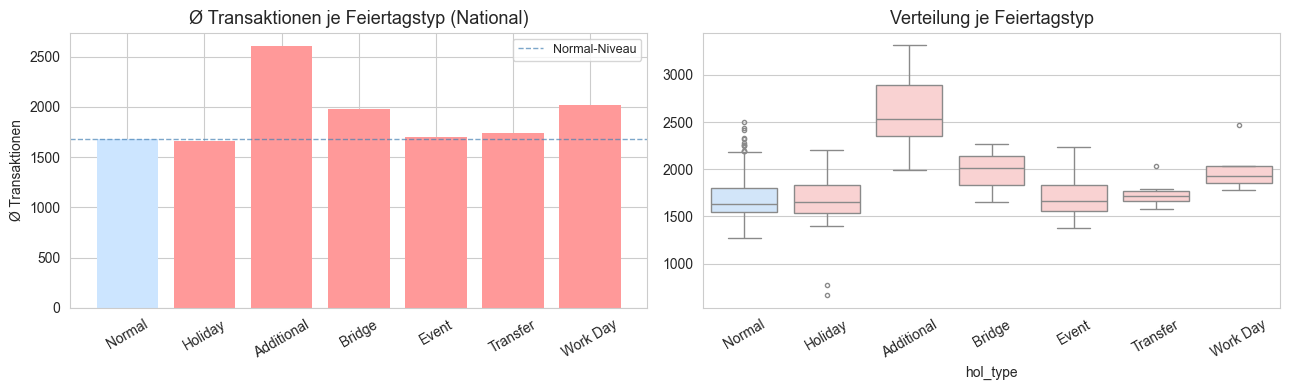

Mittelwert je Feiertagstyp (national):
              mean  count
hol_type                 
Additional  2607.5     29
Bridge      1977.3      3
Event       1700.6     56
Holiday     1658.1     46
Normal      1678.5   1540
Transfer    1741.6      7
Work Day    2014.4      5


In [14]:

order = ['Normal', 'Holiday', 'Additional', 'Bridge', 'Event', 'Transfer', 'Work Day']
order = [o for o in order if o in df_hol['hol_type'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hol_avg = df_hol.groupby('hol_type')['avg_tx'].mean().reindex(order)
colors_bar = ['#cce5ff' if h == 'Normal' else '#ff9999' for h in order]
axes[0].bar(hol_avg.index, hol_avg.values, color=colors_bar, edgecolor='none')
axes[0].axhline(hol_avg['Normal'], color='steelblue', linestyle='--',
                linewidth=1, alpha=0.7, label='Normal-Niveau')
axes[0].set_title('Ø Transaktionen je Feiertagstyp (National)', fontsize=13)
axes[0].set_ylabel('Ø Transaktionen')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

sns.boxplot(data=df_hol, x='hol_type', y='avg_tx', order=order,
            palette=['#cce5ff'] + ['#ffcccc'] * (len(order) - 1),
            flierprops={'markersize': 3}, ax=axes[1])
axes[1].set_title('Verteilung je Feiertagstyp', fontsize=13)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Mittelwert je Feiertagstyp (national):')
print(df_hol.groupby('hol_type')['avg_tx'].agg(['mean','count']).round(1))

## Analyse der Abweichung der Transaktionen vor dem Feiertag und und danach

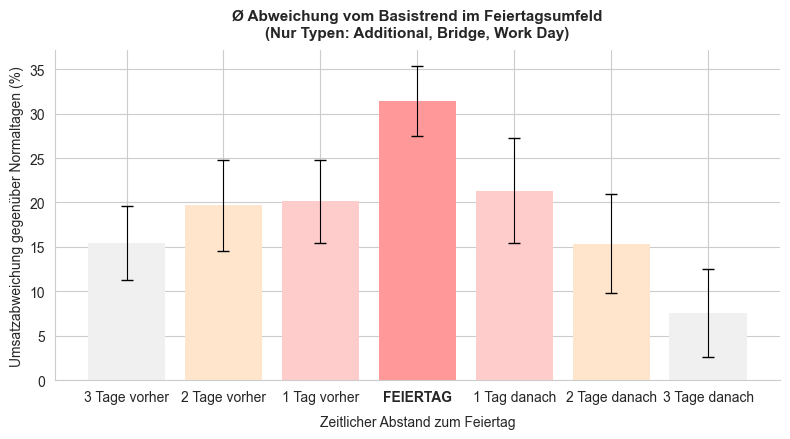

In [ ]:

hol_national = (
    hol.filter(
        (pl.col('locale') == 'National') & 
        (pl.col('type').is_in(['Additional', 'Bridge', 'Work Day']))
    )
    .select(['date', 'type'])
    .rename({'type': 'hol_type'})
).to_pandas()

df_hol = daily_avg.merge(hol_national, on='date', how='left')
df_hol["hol_type"] = df_hol["hol_type"].fillna("Normal")

window = range(-3, 4)
records = []

for idx, row in df_hol[df_hol['hol_type'] != 'Normal'].iterrows():
    hol_date = row['date']
    weekday = pd.Timestamp(hol_date).weekday()
    month = pd.Timestamp(hol_date).month

    baseline = df_hol[
        (df_hol['hol_type'] == 'Normal') &
        (pd.to_datetime(df_hol['date']).dt.weekday == weekday) &
        (pd.to_datetime(df_hol['date']).dt.month == month)
    ]['avg_tx'].mean()

    if pd.isna(baseline) or baseline == 0:
        continue

    for offset in window:
        target_date = pd.Timestamp(hol_date) + pd.Timedelta(days=offset)
        match = df_hol[df_hol['date'] == target_date]
        if not match.empty:
            val = match['avg_tx'].values[0]
            records.append({
                'offset': offset,
                'pct_deviation': (val - baseline) / baseline * 100
            })

window_df = pd.DataFrame(records)
window_agg = window_df.groupby('offset')['pct_deviation'].agg(['mean', 'sem']).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))

colors_win = [
    '#ff9999' if o == 0 else
    '#ffcccc' if abs(o) == 1 else
    '#ffe5cc' if abs(o) == 2 else
    '#f0f0f0'
    for o in window_agg['offset']
]

ax.bar(window_agg['offset'], window_agg['mean'],
       color=colors_win, edgecolor='none',
       yerr=window_agg['sem'], capsize=4, error_kw={'linewidth': 0.8})

ax.set_title('Ø Abweichung vom Basistrend im Feiertagsumfeld\n(Nur Typen: Additional, Bridge, Work Day)', 
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Zeitlicher Abstand zum Feiertag', fontsize=10, labelpad=8)
ax.set_ylabel('Umsatzabweichung gegenüber Normaltagen (%)', fontsize=10)

ax.set_xticks(list(window))
x_labels = [
    '3 Tage vorher', 
    '2 Tage vorher', 
    '1 Tag vorher', 
    'FEIERTAG', 
    '1 Tag danach', 
    '2 Tage danach', 
    '3 Tage danach'
]
ax.set_xticklabels(x_labels, fontweight='normal')
ax.get_xticklabels()[3].set_fontweight('bold')

sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

## Zusatgrafiken

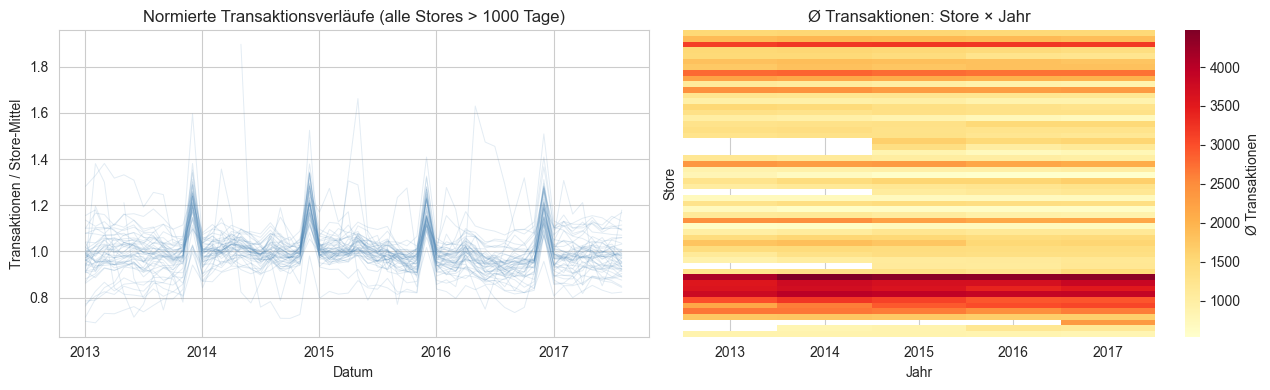

In [18]:
tx_pd = tx.to_pandas()

store_means = tx_pd.groupby('store_nbr')['transactions'].transform('mean')
tx_pd['tx_normalized'] = tx_pd['transactions'] / store_means

long_stores = tx_pd.groupby('store_nbr').filter(lambda g: len(g) > 1000)
monthly = (
    long_stores.assign(month=long_stores['date'].values.astype('datetime64[M]'))
    .groupby(['month', 'store_nbr'])['tx_normalized'].mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for store_id, grp in monthly.groupby('store_nbr'):
    axes[0].plot(grp['month'], grp['tx_normalized'],
                 alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].set_title('Normierte Transaktionsverläufe (alle Stores > 1000 Tage)', fontsize=12)
axes[0].set_ylabel('Transaktionen / Store-Mittel')
axes[0].set_xlabel('Datum')

store_year = (
    df.group_by(['store_nbr', 'year'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .to_pandas()
    .pivot(index='store_nbr', columns='year', values='avg')
)
sns.heatmap(store_year, cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Ø Transaktionen'},
            xticklabels=True, yticklabels=False)
axes[1].set_title('Ø Transaktionen: Store × Jahr', fontsize=12)
axes[1].set_xlabel('Jahr')
axes[1].set_ylabel('Store')

plt.tight_layout()
plt.show()

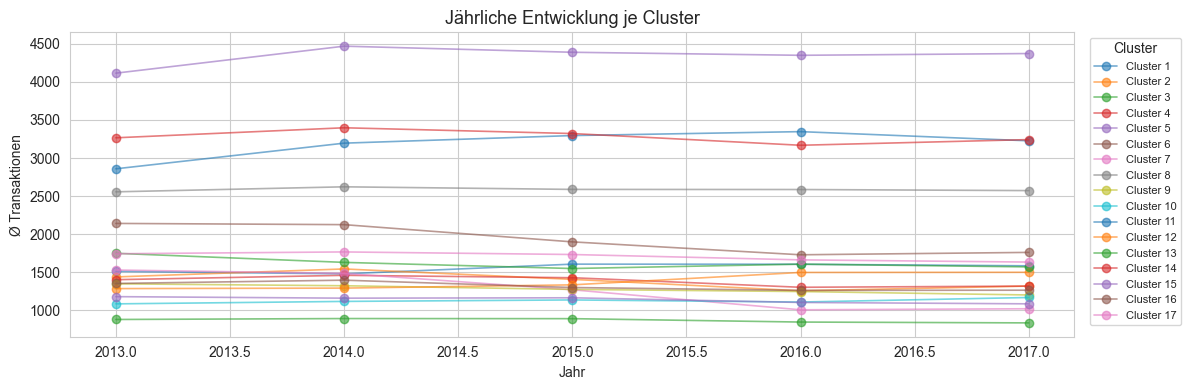

In [19]:
cluster_avg = (
    df.group_by(['cluster', 'year'])
    .agg(pl.col('transactions').mean().alias('avg'))
    .sort(['cluster', 'year'])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
for cluster_id, grp in cluster_avg.groupby('cluster'):
    ax.plot(grp['year'], grp['avg'], marker='o', alpha=0.6,
            linewidth=1.2, label=f'Cluster {cluster_id}')
ax.set_title('Jährliche Entwicklung je Cluster', fontsize=13)
ax.set_ylabel('Ø Transaktionen')
ax.set_xlabel('Jahr')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
          ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

## 7 · Fazit & Feature-Engineering-Entscheidungen

| Befund | Feature |
|---|---|
| Starke Wochensaisonalität (ACF Lag 7 ≈ 0.76) | Lags: 1, 7, 14 sind Pflicht |
| Dezember-Peak sichtbar | Zyklische Monats-Features (sin/cos) |
| Samstag / Sonntag deutlich erhöht | Wochentag als kategorisches Feature |
| Ölpreis schwach korreliert (r ≈ 0.10) | Als exogener Regressor mit Interpolation aufnehmen |
| Feiertage: +12% im Mittel, `Additional` und `Work Day` am stärksten | Holiday-Flag + Typ als Feature |
| Stores unterscheiden sich im Level, nicht im Muster | Normierung oder Store-ID als kategorisches Embedding sinnvoll |
| Kein starker Jahres-Trend | Kein explizites Trend-Feature nötig |

In [21]:
# Basisanalyse als Parquet für spätere Referenz speichern
pl.from_pandas(daily_avg).write_parquet(PROCESSED / 'daily_avg_all_stores.parquet')
print('daily_avg_all_stores.parquet gespeichert.')

daily_avg_all_stores.parquet gespeichert.
